In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
%pip install xgboost streamlit requests beautifulsoup4 joblib plotly

Note: you may need to restart the kernel to use updated packages.


In [3]:
matches = pd.read_csv('../data/all_ipl_matches_data.csv')
deliveries = pd.read_csv('../data/all_ball_by_ball_data.csv')
players = pd.read_csv('../data/all_players-data-updated.csv')
teams = pd.read_csv('../data/all_teams_data.csv')
print('matches shape:', matches.shape)
print('deliveries shape:', deliveries.shape)
print('players shape:', players.shape)
print('teams shape:', teams.shape)


matches shape: (1169, 23)
deliveries shape: (278205, 30)
players shape: (772, 6)
teams shape: (16, 2)


In [4]:
print('matches columns:', matches.columns.tolist())
print('deliveries columns:', deliveries.columns.tolist())
print('players columns:', players.columns.tolist())
print('teams columns:', teams.columns.tolist())


matches columns: ['match_id', 'season_id', 'balls_per_over', 'city', 'match_date', 'event_name', 'match_number', 'gender', 'match_type', 'format', 'overs', 'season', 'team_type', 'venue', 'toss_winner', 'team1', 'team2', 'toss_decision', 'match_winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'result']
deliveries columns: ['season_id', 'match_id', 'batter', 'bowler', 'non_striker', 'team_batting', 'team_bowling', 'over_number', 'ball_number', 'batter_runs', 'extras', 'total_runs', 'batsman_type', 'bowler_type', 'player_out', 'fielders_involved', 'is_wicket', 'is_wide_ball', 'is_no_ball', 'is_leg_bye', 'is_bye', 'is_penalty', 'wide_ball_runs', 'no_ball_runs', 'leg_bye_runs', 'bye_runs', 'penalty_runs', 'wicket_kind', 'is_super_over', 'innings']
players columns: ['player_id', 'player_name', 'bat_style', 'bowl_style', 'field_pos', 'player_full_name']
teams columns: ['team_id', 'team_name']


In [5]:
matches.head()

,match_id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,...,venue,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,player_of_match,result
0,335982,2008,6,Bangalore,2008-04-18,Indian Premier League,1.0,male,T20,T20,...,M Chinnaswamy Stadium,1,1,6,field,6,140.0,NaN,46.0,win
1,1082591,2017,6,Hyderabad,2017-04-05,Indian Premier League,1.0,male,T20,T20,...,"Rajiv Gandhi International Stadium, Uppal",1,2,1,field,2,35.0,NaN,15.0,win
2,1082592,2017,6,Pune,2017-04-06,Indian Premier League,2.0,male,T20,T20,...,Maharashtra Cricket Association Stadium,4,4,3,field,4,NaN,7.0,36.0,win
3,1082593,2017,6,Rajkot,2017-04-07,Indian Premier League,3.0,male,T20,T20,...,Saurashtra Cricket Association Stadium,6,5,6,field,6,NaN,10.0,57.0,win
4,1082594,2017,6,Indore,2017-04-08,Indian Premier League,4.0,male,T20,T20,...,Holkar Cricket Stadium,494,494,4,field,494,NaN,6.0,71.0,win


In [6]:
deliveries.head()

,season_id,match_id,batter,bowler,non_striker,team_batting,team_bowling,over_number,ball_number,batter_runs,...,is_bye,is_penalty,wide_ball_runs,no_ball_runs,leg_bye_runs,bye_runs,penalty_runs,wicket_kind,is_super_over,innings
0,2008,335982,SC Ganguly,P Kumar,BB McCullum,6,1,0,0,0,...,False,False,0,0,1,0,0,NaN,False,1
1,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,1,0,...,False,False,0,0,0,0,0,NaN,False,1
2,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,2,0,...,False,False,1,0,0,0,0,NaN,False,1
3,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,3,0,...,False,False,0,0,0,0,0,NaN,False,1
4,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,4,0,...,False,False,0,0,0,0,0,NaN,False,1


In [7]:
players.head()

,player_id,player_name,bat_style,bowl_style,field_pos,player_full_name
0,6730,Mohsin Khan,Left hand Bat,Left arm Medium fast,NaN,Mohsin Khan
1,22,Rashid Khan,Right hand Bat,Legbreak Googly,,Rashid Khan Arman
2,590,K Rabada,Left hand Bat,Right arm Fast,,Kagiso Rabada
3,1424,SN Khan,Right hand Bat,Legbreak,,Sarfaraz Naushad Khan
4,963,MN Samuels,Right hand Bat,Right arm Offbreak,,Marlon Nathaniel Samuels


In [8]:
teams.head()

,team_id,team_name
0,1,Royal Challengers Bangalore
1,2,Sunrisers Hyderabad
2,3,Mumbai Indians
3,4,Rising Pune Supergiant
4,5,Gujarat Lions


**Build Team ID to Name Mapping**


In [9]:
team_map = dict(zip(teams['team_id'], teams['team_name']))
team_map

{1: 'Royal Challengers Bangalore',
 2: 'Sunrisers Hyderabad',
 3: 'Mumbai Indians',
 4: 'Rising Pune Supergiant',
 5: 'Gujarat Lions',
 6: 'Kolkata Knight Riders',
 129: 'Chennai Super Kings',
 134: 'Rajasthan Royals',
 252: 'Delhi Capitals',
 494: 'Punjab Kings',
 614: 'Lucknow Super Giants',
 615: 'Gujarat Titans',
 1068: 'Deccan Chargers',
 1414: 'Kochi Tuskers Kerala',
 1419: 'Pune Warriors',
 3604: 'Rising Pune Supergiants'}

**Applying Mapping to Matches + Clean**

In [10]:
matches['team1'] = matches['team1'].map(team_map)
matches['team2'] = matches['team2'].map(team_map)


In [11]:
matches['toss_winner'] = matches['toss_winner'].map(team_map)
matches['winner'] = matches['match_winner'].map(team_map)



In [12]:
matches.rename(columns={'match_id': 'id'}, inplace=True)
matches = matches[matches['result'] == 'win'].reset_index(drop=True)
matches['match_date'] = pd.to_datetime(matches['match_date'], errors='coerce')
matches = matches.sort_values('match_date').reset_index(drop=True)

In [13]:
print("Matches after cleaning:", matches.shape)
print(matches[['id', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'venue', 'season']].head(5))


Matches after cleaning: (1146, 24)
       id                        team1                        team2  \
0  335982  Royal Challengers Bangalore        Kolkata Knight Riders   
1  335984               Delhi Capitals             Rajasthan Royals   
2  335983                 Punjab Kings          Chennai Super Kings   
3  335985               Mumbai Indians  Royal Challengers Bangalore   
4  335986        Kolkata Knight Riders          Sunrisers Hyderabad   

                   toss_winner toss_decision                       winner  \
0  Royal Challengers Bangalore         field        Kolkata Knight Riders   
1             Rajasthan Royals           bat               Delhi Capitals   
2          Chennai Super Kings           bat          Chennai Super Kings   
3               Mumbai Indians           bat  Royal Challengers Bangalore   
4          Sunrisers Hyderabad           bat        Kolkata Knight Riders   

                                        venue season  
0                   

**Applying Mapping to Deliveries + Rename Columns**


In [14]:
deliveries['batting_team'] = deliveries['team_batting'].map(team_map)
deliveries['bowling_team'] = deliveries['team_bowling'].map(team_map)

In [15]:
deliveries.columns.tolist()  

['season_id',
 'match_id',
 'batter',
 'bowler',
 'non_striker',
 'team_batting',
 'team_bowling',
 'over_number',
 'ball_number',
 'batter_runs',
 'extras',
 'total_runs',
 'batsman_type',
 'bowler_type',
 'player_out',
 'fielders_involved',
 'is_wicket',
 'is_wide_ball',
 'is_no_ball',
 'is_leg_bye',
 'is_bye',
 'is_penalty',
 'wide_ball_runs',
 'no_ball_runs',
 'leg_bye_runs',
 'bye_runs',
 'penalty_runs',
 'wicket_kind',
 'is_super_over',
 'innings',
 'batting_team',
 'bowling_team']

In [16]:
deliveries.rename(columns={'batter': 'batsman', 'batter_runs': 'batsman_runs', 'wicket_kind': 'dismissal_kind',
'innings': 'inning'}, inplace=True)

In [17]:
print("Deliveries after cleaning:", deliveries.shape)
print(deliveries[['match_id', 'batsman', 'bowler', 'batsman_runs', 'total_runs', 'batting_team', 'bowling_team',
'dismissal_kind', 'inning']].head(5))

Deliveries after cleaning: (278205, 32)
   match_id      batsman   bowler  batsman_runs  total_runs  \
0    335982   SC Ganguly  P Kumar             0           1   
1    335982  BB McCullum  P Kumar             0           0   
2    335982  BB McCullum  P Kumar             0           1   
3    335982  BB McCullum  P Kumar             0           0   
4    335982  BB McCullum  P Kumar             0           0   

            batting_team                 bowling_team dismissal_kind  inning  
0  Kolkata Knight Riders  Royal Challengers Bangalore            NaN       1  
1  Kolkata Knight Riders  Royal Challengers Bangalore            NaN       1  
2  Kolkata Knight Riders  Royal Challengers Bangalore            NaN       1  
3  Kolkata Knight Riders  Royal Challengers Bangalore            NaN       1  
4  Kolkata Knight Riders  Royal Challengers Bangalore            NaN       1  


**Explore Matches**

In [18]:
print("Seasons covered:")
print(sorted(matches['season'].unique()))

Seasons covered:
['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025']


In [19]:
print("Total matches:", len(matches))

Total matches: 1146


In [20]:
print("Total unique teams:", len(matches['team1'].unique()))

Total unique teams: 14


In [21]:
print("Total venues:", matches['venue'].unique())

Total venues: ['M Chinnaswamy Stadium' 'Feroz Shah Kotla'
 'Punjab Cricket Association Stadium, Mohali' 'Wankhede Stadium'
 'Eden Gardens' 'Sawai Mansingh Stadium'
 'Rajiv Gandhi International Stadium, Uppal'
 'MA Chidambaram Stadium, Chepauk' 'Dr DY Patil Sports Academy' 'Newlands'
 "St George's Park" 'Kingsmead' 'SuperSport Park' 'Buffalo Park'
 'New Wanderers Stadium' 'De Beers Diamond Oval' 'OUTsurance Oval'
 'Brabourne Stadium' 'Sardar Patel Stadium, Motera' 'Barabati Stadium'
 'Brabourne Stadium, Mumbai'
 'Vidarbha Cricket Association Stadium, Jamtha'
 'Himachal Pradesh Cricket Association Stadium' 'Nehru Stadium'
 'Holkar Cricket Stadium'
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium'
 'Subrata Roy Sahara Stadium' 'Maharashtra Cricket Association Stadium'
 'Shaheed Veer Narayan Singh International Stadium'
 'JSCA International Stadium Complex' 'Sheikh Zayed Stadium'
 'Sharjah Cricket Stadium' 'Dubai International Cricket Stadium'
 'Punjab Cricket Association IS Bindra St

In [22]:
print('toss decisions')
print(matches['toss_decision'].value_counts())

toss decisions
toss_decision
field    750
bat      396
Name: count, dtype: int64


In [23]:
print('null values in key columns:')
print(matches[['team1','team2','winner','venue','toss_winner','toss_decision']].isnull().sum())


null values in key columns:
team1            0
team2            0
winner           0
venue            0
toss_winner      0
toss_decision    0
dtype: int64


**Explore Deliveries**

In [24]:
print('total balls bowled:', len(deliveries))
print('unique batsmen:', deliveries['batsman'].nunique())
print('unique bowlers:', deliveries['bowler'].nunique())
print("innings values:", deliveries['inning'].unique())
print("dismissal kinds:", deliveries['dismissal_kind'].dropna().unique())
print("null values in key columns:", deliveries[['batsman', 'bowler', 'batsman_runs', 'total_runs']].isnull().sum())

total balls bowled: 278205
unique batsmen: 703
unique bowlers: 550
innings values: [1 2 3 4 5 6]
dismissal kinds: ['caught' 'bowled' 'run out' 'lbw' 'caught and bowled' 'stumped'
 'retired hurt' 'hit wicket' 'obstructing the field' 'retired out']
null values in key columns: batsman         0
bowler          0
batsman_runs    0
total_runs      0
dtype: int64


In [25]:
dismissal_types = ['bowled', 'caught', 'lbw', 'stumped', 
                   'caught and bowled', 'hit wicket', 'run out']
dismissals_df = (
    deliveries[deliveries['dismissal_kind'].isin(dismissal_types)]
    .groupby('batsman').size()
    .reset_index(name='dismissals'))

**Computeing Batting Stats**


In [26]:
batting = deliveries.groupby('batsman').agg(
    total_runs=('batsman_runs', 'sum'),
    balls_faced=('ball_number', 'count'),
    innings_played=('match_id', 'nunique')
).reset_index()

In [27]:
batting = batting.merge(dismissals_df, on='batsman', how='left')
batting['dismissals'] = batting['dismissals'].fillna(0)

In [28]:
batting['dismissals'] = batting['dismissals'].fillna(0)
batting['batting_avg'] = np.where(batting['dismissals'] > 0, 
                                  batting['total_runs'] / batting['dismissals'], batting['total_runs'])

In [29]:
batting

,batsman,total_runs,balls_faced,innings_played,dismissals,batting_avg
0,A Ashish Reddy,280,196,23,15.0,18.666667
1,A Badoni,963,740,46,36.0,26.750000
2,A Chandila,4,7,2,1.0,4.000000
3,A Chopra,53,75,6,5.0,10.600000
4,A Choudhary,25,20,3,2.0,12.500000
...,...,...,...,...,...,...
698,Yashpal Singh,47,67,4,4.0,11.750000
699,Younis Khan,3,7,1,1.0,3.000000
700,Yudhvir Singh,22,16,4,4.0,5.500000
701,Yuvraj Singh,2754,2207,126,109.0,25.266055


In [30]:
deliveries

,season_id,match_id,batsman,bowler,non_striker,team_batting,team_bowling,over_number,ball_number,batsman_runs,...,wide_ball_runs,no_ball_runs,leg_bye_runs,bye_runs,penalty_runs,dismissal_kind,is_super_over,inning,batting_team,bowling_team
0,2008,335982,SC Ganguly,P Kumar,BB McCullum,6,1,0,0,0,...,0,0,1,0,0,NaN,False,1,Kolkata Knight Riders,Royal Challengers Bangalore
1,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,1,0,...,0,0,0,0,0,NaN,False,1,Kolkata Knight Riders,Royal Challengers Bangalore
2,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,2,0,...,1,0,0,0,0,NaN,False,1,Kolkata Knight Riders,Royal Challengers Bangalore
3,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,3,0,...,0,0,0,0,0,NaN,False,1,Kolkata Knight Riders,Royal Challengers Bangalore
4,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,4,0,...,0,0,0,0,0,NaN,False,1,Kolkata Knight Riders,Royal Challengers Bangalore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278200,2025,1485779,T Stubbs,Arshdeep Singh,Sameer Rizvi,252,494,18,5,4,...,0,0,0,0,0,NaN,False,2,Delhi Capitals,Punjab Kings
278201,2025,1485779,Sameer Rizvi,MP Stoinis,T Stubbs,252,494,19,0,0,...,1,0,0,0,0,NaN,False,2,Delhi Capitals,Punjab Kings
278202,2025,1485779,Sameer Rizvi,MP Stoinis,T Stubbs,252,494,19,1,1,...,0,0,0,0,0,NaN,False,2,Delhi Capitals,Punjab Kings
278203,2025,1485779,T Stubbs,MP Stoinis,Sameer Rizvi,252,494,19,2,1,...,0,0,0,0,0,NaN,False,2,Delhi Capitals,Punjab Kings


In [31]:
batting['strike_rate'] = (batting['total_runs'] / batting['balls_faced']) * 100
batting['batting_avg'] = np.where(
    batting['dismissals'] > 0,
    batting['total_runs'] / batting['dismissals'],
    batting['total_runs'])
batting = batting[batting['innings_played'] > 5].reset_index(drop=True)

batting.columns = ['player', 'total_runs', 'balls_faced', 'innings',
                   'dismissals', 'strike_rate', 'batting_avg']




In [32]:
batting.columns

Index(['player', 'total_runs', 'balls_faced', 'innings', 'dismissals',
       'strike_rate', 'batting_avg'],
      dtype='object')

In [33]:
batting.columns

Index(['player', 'total_runs', 'balls_faced', 'innings', 'dismissals',
       'strike_rate', 'batting_avg'],
      dtype='object')

In [34]:
batting.shape

(423, 7)

In [35]:
print(batting.nlargest(10,'batting_avg')[['player','batting_avg','strike_rate','total_runs','balls_faced','innings']])

              player  batting_avg  strike_rate  total_runs  balls_faced  \
296       R Shepherd   198.924731    23.125000         185           93   
402    V Suryavanshi   195.348837    36.000000         252          129   
145  J Fraser-McGurk   189.655172    27.500000         385          203   
6           A Mhatre   183.206107    34.285714         240          131   
377    Shahid Afridi   176.086957    10.125000          81           46   
283    Priyansh Arya   175.806452    30.277778         545          310   
257       Naman Dhir   173.451327    28.000000         392          226   
399          V Nigam   173.170732    28.400000         142           82   
272          PD Salt   169.502408    33.000000        1056          623   
176        KK Cooper   165.714286    12.888889         116           70   

     innings  
296       12  
402        7  
145       15  
6          7  
377        9  
283       18  
257       19  
399        8  
272       34  
176       12  


**Computeing Bowling Stats**

In [36]:
player_match_sr = (
    deliveries.groupby(['batsman', 'match_id'])
    .agg(runs=('batsman_runs', 'sum'), balls=('ball_number', 'count'))
    .reset_index())
player_match_sr['match_sr'] = (player_match_sr['runs'] / player_match_sr['balls']) * 100
player_match_sr = player_match_sr.sort_values('match_id')


In [37]:
player_match_sr['rolling_sr'] = (
    player_match_sr.groupby('batsman')['match_sr']
    .transform(lambda x: x.rolling(5, min_periods=1).mean())
)

In [38]:
recent_sr = (
    player_match_sr.groupby('batsman')['rolling_sr']
    .last()
    .reset_index()
    .rename(columns={'batsman': 'player', 'rolling_sr': 'recent_strike_rate'})
)

In [39]:
batting = batting.merge(recent_sr, on='player', how='left')
batting['recent_strike_rate'] = batting['recent_strike_rate'].fillna(batting['strike_rate'])


In [40]:
batting.head()

,player,total_runs,balls_faced,innings,dismissals,strike_rate,batting_avg,recent_strike_rate
0,A Ashish Reddy,280,196,23,15.0,18.666667,142.857143,120.444444
1,A Badoni,963,740,46,36.0,26.750000,130.135135,138.019812
2,A Chopra,53,75,6,5.0,10.600000,70.666667,62.977778
3,A Kamboj,16,15,6,2.0,8.000000,106.666667,138.333333
4,A Kumble,35,49,15,2.0,17.500000,71.428571,63.333333


In [41]:
bowler_wicket_type=['bowled','caught','lbw','stumped','caught and bowled','hit wicket']
wicket_df=deliveries[deliveries['dismissal_kind'].isin(bowler_wicket_type)]
bowling=deliveries.groupby('bowler').agg(ball_bowled=('ball_number', 'count'),
runs_conceded=('total_runs', 'sum'),
matches=('match_id', 'nunique')).reset_index()                                       

In [42]:
bowling

,bowler,ball_bowled,runs_conceded,matches
0,A Ashish Reddy,270,400,20
1,A Badoni,35,50,7
2,A Chandila,234,245,12
3,A Choudhary,108,144,5
4,A Dananjaya,25,47,1
...,...,...,...,...
545,Yash Thakur,475,782,21
546,Yudhvir Singh,145,257,9
547,Yuvraj Singh,882,1091,73
548,Z Khan,2276,2860,99


In [43]:
wicketes = wicket_df.groupby('bowler').size().reset_index(name='wickets')
bowling = bowling.merge(wicketes, on='bowler', how='left')
bowling['wickets'] = bowling['wickets'].fillna(0)
bowling['economy'] = (bowling['runs_conceded'] / (bowling['ball_bowled'] / 6))
bowling['bowling_avg'] = bowling['runs_conceded'] / bowling['wickets'].replace(0, np.nan)

bowler_over_economy = deliveries.groupby(['bowler', 'match_id', 'over_number'])['total_runs'].sum().reset_index()
bowler_over_economy.columns = ['bowler', 'match_id', 'over_number', 'runs_in_over']
bowler_over_economy['over_economy'] = bowler_over_economy['runs_in_over']
bowler_recent_eco = (
bowler_over_economy.groupby('bowler')['over_economy']
.apply(lambda x: x.rolling(window=30, min_periods=1).mean().iloc[-1], include_groups=False).reset_index())
bowler_recent_eco.columns = ['bowler','recent_economy']

bowling = bowling.merge(bowler_recent_eco, on='bowler', how='left')
bowling['recent_economy'] = bowling['recent_economy'].fillna(bowling['economy'])

In [44]:
bowling

,bowler,ball_bowled,runs_conceded,matches,wickets,economy,bowling_avg,recent_economy
0,A Ashish Reddy,270,400,20,18.0,8.888889,22.222222,9.000000
1,A Badoni,35,50,7,4.0,8.571429,12.500000,7.142857
2,A Chandila,234,245,12,11.0,6.282051,22.272727,6.400000
3,A Choudhary,108,144,5,5.0,8.000000,28.800000,8.470588
4,A Dananjaya,25,47,1,0.0,11.280000,NaN,11.750000
...,...,...,...,...,...,...,...,...
545,Yash Thakur,475,782,21,25.0,9.877895,31.280000,12.066667
546,Yudhvir Singh,145,257,9,8.0,10.634483,32.125000,11.173913
547,Yuvraj Singh,882,1091,73,36.0,7.421769,30.305556,8.333333
548,Z Khan,2276,2860,99,102.0,7.539543,28.039216,7.800000


In [45]:
bowling.columns = ['player', 'ball_bowled', 'runs_conceded', 'matches', 
                   'wickets', 'economy', 'bowling_avg', 'recent_economy']
print("Bowling columns:", bowling.columns.tolist())


Bowling columns: ['player', 'ball_bowled', 'runs_conceded', 'matches', 'wickets', 'economy', 'bowling_avg', 'recent_economy']


In [46]:
bowling.shape

(550, 8)

In [47]:
top_bowl=bowling[bowling['matches'] >=20].nsmallest(10,'economy')

In [48]:
print(top_bowl[['player','economy','bowling_avg','wickets','matches']])

               player   economy  bowling_avg  wickets  matches
7            A Kumble  6.646999    24.200000     45.0       42
271    M Muralitharan  6.698292    27.578125     64.0       66
188           J Yadav  6.738693    55.875000      8.0       20
391  RE van der Merwe  6.791209    24.523810     21.0       21
141          DW Steyn  6.791411    26.628866     97.0       95
460         SP Narine  6.825153    26.192708    192.0      187
132        DL Vettori  6.833121    31.928571     28.0       34
182           J Botha  6.922426    32.720000     25.0       34
452        SL Malinga  7.032952    20.505882    170.0      122
167   Harbhajan Singh  7.038330    27.340000    150.0      160


**Mergeing into Player Lookup + Save**

In [49]:
player_lookup = pd.merge(batting, bowling, on='player', how='outer')


In [50]:
player_lookup['wickets'] = player_lookup['wickets'].fillna(0)
player_lookup['innings'] = player_lookup['innings'].fillna(0)
player_lookup['total_runs'] = player_lookup['total_runs'].fillna(0)

In [51]:
player_lookup.shape

(683, 15)

In [52]:
player_lookup.head(10)

,player,total_runs,balls_faced,innings,dismissals,strike_rate,batting_avg,recent_strike_rate,ball_bowled,runs_conceded,matches,wickets,economy,bowling_avg,recent_economy
0,A Ashish Reddy,280.0,196.0,23.0,15.0,18.666667,142.857143,120.444444,270.0,400.0,20.0,18.0,8.888889,22.222222,9.000000
1,A Badoni,963.0,740.0,46.0,36.0,26.750000,130.135135,138.019812,35.0,50.0,7.0,4.0,8.571429,12.500000,7.142857
2,A Chandila,0.0,NaN,0.0,NaN,NaN,NaN,NaN,234.0,245.0,12.0,11.0,6.282051,22.272727,6.400000
3,A Chopra,53.0,75.0,6.0,5.0,10.600000,70.666667,62.977778,NaN,NaN,NaN,0.0,NaN,NaN,NaN
4,A Choudhary,0.0,NaN,0.0,NaN,NaN,NaN,NaN,108.0,144.0,5.0,5.0,8.000000,28.800000,8.470588
5,A Dananjaya,0.0,NaN,0.0,NaN,NaN,NaN,NaN,25.0,47.0,1.0,0.0,11.280000,NaN,11.750000
6,A Flintoff,0.0,NaN,0.0,NaN,NaN,NaN,NaN,66.0,106.0,3.0,2.0,9.636364,53.000000,9.636364
7,A Kamboj,16.0,15.0,6.0,2.0,8.000000,106.666667,138.333333,198.0,288.0,11.0,10.0,8.727273,28.800000,8.500000
8,A Kumble,35.0,49.0,15.0,2.0,17.500000,71.428571,63.333333,983.0,1089.0,42.0,45.0,6.646999,24.200000,7.233333
9,A Manohar,292.0,243.0,20.0,19.0,15.368421,120.164609,63.243243,NaN,NaN,NaN,0.0,NaN,NaN,NaN


In [53]:
print(player_lookup.columns.tolist())

['player', 'total_runs', 'balls_faced', 'innings', 'dismissals', 'strike_rate', 'batting_avg', 'recent_strike_rate', 'ball_bowled', 'runs_conceded', 'matches', 'wickets', 'economy', 'bowling_avg', 'recent_economy']


In [54]:
for col in ['batting_avg', 'strike_rate', 'recent_strike_rate',
            'economy', 'recent_economy', 'bowling_avg']:
    median_val = player_lookup[col].median()
    player_lookup[col] = player_lookup[col].fillna(median_val)

In [55]:
player_lookup.to_csv('../player_stats/player_lookup.csv', index=False)

**Match Feature Engineering**

In [56]:
player_lookup=pd.read_csv('../player_stats/player_lookup.csv')

In [57]:
player_lookup.head()

,player,total_runs,balls_faced,innings,dismissals,strike_rate,batting_avg,recent_strike_rate,ball_bowled,runs_conceded,matches,wickets,economy,bowling_avg,recent_economy
0,A Ashish Reddy,280.0,196.0,23.0,15.0,18.666667,142.857143,120.444444,270.0,400.0,20.0,18.0,8.888889,22.222222,9.000000
1,A Badoni,963.0,740.0,46.0,36.0,26.750000,130.135135,138.019812,35.0,50.0,7.0,4.0,8.571429,12.500000,7.142857
2,A Chandila,0.0,NaN,0.0,NaN,19.727273,118.803419,93.821429,234.0,245.0,12.0,11.0,6.282051,22.272727,6.400000
3,A Chopra,53.0,75.0,6.0,5.0,10.600000,70.666667,62.977778,NaN,NaN,NaN,0.0,8.529554,31.396129,9.100000
4,A Choudhary,0.0,NaN,0.0,NaN,19.727273,118.803419,93.821429,108.0,144.0,5.0,5.0,8.000000,28.800000,8.470588


In [58]:
player_lookup.shape

(683, 15)

**Compute Opening Batsmen Stats Per Team**

In [59]:
batting_order = (
    deliveries[deliveries['inning'] == 1]
    .groupby(['match_id','batting_team'])['batsman']
    .apply(list, include_groups=False)
    .reset_index())
batting_order.columns = ['match_id','team','batting_order']
batting_order['opener1'] = batting_order['batting_order'].apply(
    lambda x: x[0] if len(x) > 0 else None)
batting_order['opener2'] = batting_order['batting_order'].apply(
    lambda x: next((p for p in x if p != x[0]), None) if len(x) > 1 else None)

In [60]:
def get_opener_stats(team,player_lookup,batting_order) :
    team_openers = batting_order[batting_order['team'] == team]
    all_openers=pd.concat([team_openers['opener1'].dropna(), team_openers['opener2'].dropna()])
    if all_openers.empty:
        return {'opener_avg_batting_avg': 25, 'opener_avg_strike_rate': 130}
    top_openers=all_openers.value_counts().head(3).index.tolist()
    opener_stats=player_lookup[player_lookup['player'].isin(top_openers)]
    return {
        'opener_avg_batting_avg': opener_stats['batting_avg'].mean(),
        'opener_avg_strike_rate': opener_stats['strike_rate'].mean()
    }

team_list=matches['team1'].unique().tolist()
team_oppener_lookup={}
for team in team_list:
    if pd.notna(team):
        team_oppener_lookup[team]=get_opener_stats(team,player_lookup,batting_order)

print(len(team_oppener_lookup), "teams")
print("Sample:", list(team_oppener_lookup.items())[:2])


14 teams
Sample: [('Royal Challengers Bangalore', {'opener_avg_batting_avg': np.float64(134.63348807233297), 'opener_avg_strike_rate': np.float64(37.310471530784035)}), ('Delhi Capitals', {'opener_avg_batting_avg': np.float64(142.49395823462672), 'opener_avg_strike_rate': np.float64(30.8169487307118)})]


**Team Stats from XI**

In [61]:
def get_team_stats(player_list, player_lookup):

    stats = player_lookup[player_lookup['player'].isin(player_list)]

    if stats.empty:
        return {
            'avg_batting_avg': 25,
            'avg_strike_rate': 120,
            'top3_batting_avg': 30,
            'avg_economy': 8.5,
            'avg_bowling_avg': 30,
            'recent_strike_rate': 120,
            'recent_economy': 8.5
        }

    return {
        'avg_batting_avg'   : stats['batting_avg'].mean(),
        'avg_strike_rate'   : stats['strike_rate'].mean(),
        'top3_batting_avg'  : stats.nlargest(3, 'batting_avg')['batting_avg'].mean(),
        'avg_economy'       : stats['economy'].replace(0, np.nan).mean(),
        'avg_bowling_avg'   : stats['bowling_avg'].replace(0, np.nan).mean(),
        'recent_strike_rate': stats['recent_strike_rate'].mean(),
        'recent_economy'    : stats['recent_economy'].replace(0, np.nan).mean()}

**Head to Head**

In [62]:
def get_h2h(team1, team2, matches, current_date):
    
  
    past_matches = matches[matches['match_date'] < current_date]

    
    h2h = past_matches[
        ((past_matches['team1'] == team1) & (past_matches['team2'] == team2)) |
        ((past_matches['team1'] == team2) & (past_matches['team2'] == team1))
    ]
    t1_wins = len(h2h[h2h['winner'] == team1])
    t2_wins = len(h2h[h2h['winner'] == team2])
    return t1_wins, t2_wins
    
    

**TEAM Chase Win %**

In [63]:
def get_chase_win_pct(team, matches, current_date):
   
    past_matches = matches[matches['match_date'] < current_date]
    chasing = past_matches[past_matches['team2'] == team]
    if len(chasing) == 0:
        return 0.5
    wins = len(chasing[chasing['winner'] == team])
    return wins / len(chasing)


**Geting Playing XI per Match**

In [64]:
team_xi = (
    deliveries.groupby(['match_id','batting_team'])['batsman']
    .apply(lambda x: list(x.unique()), include_groups=False)
    .reset_index())
team_xi.columns = ['match_id','team','players']
print(team_xi.shape)
team_xi.head()

(2333, 3)


,match_id,team,players
0,335982,Kolkata Knight Riders,"[SC Ganguly, BB McCullum, RT Ponting, DJ Husse..."
1,335982,Royal Challengers Bangalore,"[R Dravid, W Jaffer, V Kohli, JH Kallis, CL Wh..."
2,335983,Chennai Super Kings,"[ML Hayden, SK Raina, PA Patel, MEK Hussey, MS..."
3,335983,Punjab Kings,"[K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh..."
4,335984,Delhi Capitals,"[G Gambhir, V Sehwag, S Dhawan]"


**Building Feature Dataset**

In [65]:
matches.head()

,id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,...,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,player_of_match,result,winner
0,335982,2008,6,Bangalore,2008-04-18,Indian Premier League,1.0,male,T20,T20,...,Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,field,6,140.0,NaN,46.0,win,Kolkata Knight Riders
1,335984,2008,6,Delhi,2008-04-19,Indian Premier League,3.0,male,T20,T20,...,Rajasthan Royals,Delhi Capitals,Rajasthan Royals,bat,252,NaN,9.0,11982.0,win,Delhi Capitals
2,335983,2008,6,Chandigarh,2008-04-19,Indian Premier League,2.0,male,T20,T20,...,Chennai Super Kings,Punjab Kings,Chennai Super Kings,bat,129,33.0,NaN,11943.0,win,Chennai Super Kings
3,335985,2008,6,Mumbai,2008-04-20,Indian Premier League,5.0,male,T20,T20,...,Mumbai Indians,Mumbai Indians,Royal Challengers Bangalore,bat,1,NaN,5.0,11935.0,win,Royal Challengers Bangalore
4,335986,2008,6,Kolkata,2008-04-20,Indian Premier League,4.0,male,T20,T20,...,Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,6,NaN,5.0,11922.0,win,Kolkata Knight Riders


In [66]:
def get_last_n_wins(team, matches, current_date, n=5):
    team_matches = matches[
        ((matches['team1'] == team) | (matches['team2'] == team)) &
        (matches['match_date'] < current_date)
    ]

    team_matches = team_matches.sort_values('match_date')

    last_matches = team_matches.tail(n)

    wins = (last_matches['winner'] == team).sum()

    return wins

In [67]:
first_inn_scores = (
    deliveries[deliveries['inning'] == 1]
    .groupby('match_id')['total_runs'].sum()
    .reset_index()
    .rename(columns={'total_runs': 'first_innings_score'})
)

In [68]:
venue_score_history = first_inn_scores.merge(
    matches[['id', 'venue', 'match_date']], 
    left_on='match_id', right_on='id', how='left'
)[['match_id', 'venue', 'match_date', 'first_innings_score']]

venue_score_history = venue_score_history.sort_values('match_date')

In [69]:
def get_venue_avg_score(venue, current_date):
    past = venue_score_history[
        (venue_score_history['venue'] == venue) &
        (venue_score_history['match_date'] < current_date)
    ]
    if len(past) == 0:
        return 167
    return past['first_innings_score'].mean()

In [70]:
venue_stats = venue_score_history.groupby('venue').agg(
    avg_first_innings_score=('first_innings_score', 'mean'),
    matches_at_venue=('first_innings_score', 'count')
).reset_index()



In [71]:
def get_win_rate(team, matches, current_date, n=10):
    team_matches = matches[
        ((matches['team1'] == team) | (matches['team2'] == team)) &
        (matches['match_date'] < current_date)
    ]

    last_matches = team_matches.tail(n)

    if len(last_matches) == 0:
        return 0

    wins = (last_matches['winner'] == team).sum()

    return wins / len(last_matches)

In [72]:
matches['match_date'] = pd.to_datetime(matches['match_date'], errors='coerce')
matches = matches.sort_values('match_date').reset_index(drop=True)

In [73]:
print(matches.columns)


Index(['id', 'season_id', 'balls_per_over', 'city', 'match_date', 'event_name',
       'match_number', 'gender', 'match_type', 'format', 'overs', 'season',
       'team_type', 'venue', 'toss_winner', 'team1', 'team2', 'toss_decision',
       'match_winner', 'win_by_runs', 'win_by_wickets', 'player_of_match',
       'result', 'winner'],
      dtype='object')


In [74]:

def get_high_score_chase_win_pct(team, matches, deliveries, current_date, threshold=200):

    past = matches[matches['match_date'] < current_date].copy()

    first_inn_scores = deliveries[deliveries['inning'] == 1].groupby(
        'match_id')['total_runs'].sum().reset_index()
    first_inn_scores.columns = ['match_id', 'first_innings_score']
    past = past.merge(first_inn_scores, left_on='id', right_on='match_id', how='left')

    high_score_chases = past[
        (past['team2'] == team) &
        (past['first_innings_score'] >= threshold)
    ]

    if len(high_score_chases) == 0:
        return 0.4 

    wins = len(high_score_chases[high_score_chases['winner'] == team])
    return wins / len(high_score_chases)


first_inn_scores_all = deliveries[deliveries['inning'] == 1].groupby(
    'match_id')['total_runs'].sum().reset_index()
first_inn_scores_all.columns = ['match_id', 'first_innings_score']


pbks_pct = get_high_score_chase_win_pct('Punjab Kings', matches, deliveries, pd.Timestamp('2025-01-01'))
print(f"PBKS chasing 200+: {pbks_pct:.1%}")





PBKS chasing 200+: 38.1%


In [75]:
team_recent_score = (
    first_inn_scores
    .merge(matches[['id', 'team1', 'team2', 'match_date']], 
           left_on='match_id', right_on='id', how='left'))

In [76]:
team_inn_scores = deliveries.groupby(['match_id','batting_team','inning'])['total_runs'].sum().reset_index()

In [77]:
team_scores_long = pd.concat([
    team_recent_score[['match_id', 'match_date', 'team1', 'first_innings_score']]
    .rename(columns={'team1': 'team'}),
    team_recent_score[['match_id', 'match_date', 'team2', 'first_innings_score']]
    .rename(columns={'team2': 'team'}),
]).drop_duplicates(subset=['match_id', 'team'])
team_scores_long = team_scores_long.sort_values('match_date').reset_index(drop=True)


In [78]:
def get_team_recent_avg_score(team, current_date, n=5):
    past = team_scores_long[
        (team_scores_long['team'] == team) &
        (team_scores_long['match_date'] < current_date)
    ].tail(n)
    if len(past) == 0:
        return 167
    return past['first_innings_score'].mean()


In [79]:

first_inn_for_season = deliveries[deliveries['inning'] == 1].groupby('match_id')['total_runs'].sum().reset_index()
first_inn_for_season.columns = ['match_id', 'first_innings_score']
match_scores = matches.merge(first_inn_for_season, left_on='id', right_on='match_id', how='inner')
season_avg_scores = match_scores.groupby('season')['first_innings_score'].mean().to_dict()

In [80]:
season_avg_scores = match_scores.groupby('season')['first_innings_score'].mean().to_dict()

def get_season_avg_score(current_date):
    current_season = matches[matches['match_date'] == current_date]['season']
    if len(current_season) == 0:
        return 167
    season = current_season.iloc[0]


    season_matches = match_scores[
        (match_scores['season'] == season) &
        (match_scores['match_date'] < current_date)
    ]

    if len(season_matches) == 0:
    
        prev_avg = season_avg_scores.get(season, 167)
        return prev_avg

    return season_matches['first_innings_score'].mean()


def get_season_year(current_date):

    return current_date.year

print(" get_season_avg_score() defined")
print("Sample 2024:", get_season_avg_score(pd.Timestamp('2024-05-01')))
print("Sample 2019:", get_season_avg_score(pd.Timestamp('2019-05-01')))

 get_season_avg_score() defined
Sample 2024: 192.64583333333334
Sample 2019: 171.29787234042553


In [81]:
matches.head()

,id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,...,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,player_of_match,result,winner
0,335982,2008,6,Bangalore,2008-04-18,Indian Premier League,1.0,male,T20,T20,...,Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,field,6,140.0,NaN,46.0,win,Kolkata Knight Riders
1,335984,2008,6,Delhi,2008-04-19,Indian Premier League,3.0,male,T20,T20,...,Rajasthan Royals,Delhi Capitals,Rajasthan Royals,bat,252,NaN,9.0,11982.0,win,Delhi Capitals
2,335983,2008,6,Chandigarh,2008-04-19,Indian Premier League,2.0,male,T20,T20,...,Chennai Super Kings,Punjab Kings,Chennai Super Kings,bat,129,33.0,NaN,11943.0,win,Chennai Super Kings
3,335985,2008,6,Mumbai,2008-04-20,Indian Premier League,5.0,male,T20,T20,...,Mumbai Indians,Mumbai Indians,Royal Challengers Bangalore,bat,1,NaN,5.0,11935.0,win,Royal Challengers Bangalore
4,335986,2008,6,Kolkata,2008-04-20,Indian Premier League,4.0,male,T20,T20,...,Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,6,NaN,5.0,11922.0,win,Kolkata Knight Riders


In [82]:


home_grounds = {
    'Wankhede Stadium': 'Mumbai Indians',
    'MA Chidambaram Stadium': 'Chennai Super Kings',
    'Eden Gardens': 'Kolkata Knight Riders',
    'M Chinnaswamy Stadium': 'Royal Challengers Bengaluru',
    'Arun Jaitley Stadium': 'Delhi Capitals',
    'Sawai Mansingh Stadium': 'Rajasthan Royals',
    'Rajiv Gandhi International Stadium': 'Sunrisers Hyderabad',
    'Punjab Cricket Association Stadium, Mohali': 'Punjab Kings',
    'Narendra Modi Stadium': 'Gujarat Titans',  
    'BRSABV Ekana Cricket Stadium': 'Lucknow Super Giants', 
    'Maharashtra Cricket Association Stadium': 'Rising Pune Supergiant',
    'Holkar Cricket Stadium': 'Kings XI Punjab', 
    'Dr DY Patil Sports Academy': 'Mumbai Indians', 
}

powerplay_eco = (
    deliveries[(deliveries['inning'] == 1) & (deliveries['over_number'] <= 6)]
    .groupby(['match_id', 'bowling_team'])
    .agg(pp_runs=('total_runs', 'sum'), pp_balls=('ball_number', 'count'))
    .reset_index()
)
powerplay_eco['pp_economy'] = (powerplay_eco['pp_runs'] / powerplay_eco['pp_balls']) * 6

team_pp_eco_lookup = (
    powerplay_eco.groupby('bowling_team')['pp_economy']
    .mean()
    .to_dict()
)

rows = []
error_count = 0
error_messages = []  

for _, match in matches.iterrows():
    try:
        mid= match['id']
        team1= match['team1']
        team2= match['team2']
        venue= match['venue']
        toss_w= match['toss_winner']
        toss_d= match['toss_decision']
        winner= match['winner']
        current_date = match['match_date']

        if pd.isna(team1) or pd.isna(team2) or pd.isna(winner):
            continue

        avg_first_inn = get_venue_avg_score(venue, current_date)


        t1_xi_row = team_xi[(team_xi['match_id'] == mid) & (team_xi['team'] == team1)]
        t2_xi_row = team_xi[(team_xi['match_id'] == mid) & (team_xi['team'] == team2)]
        if t1_xi_row.empty or t2_xi_row.empty:
            continue

        t1_xi= t1_xi_row['players'].values[0]
        t2_xi= t2_xi_row['players'].values[0]
        t1_stats = get_team_stats(t1_xi, player_lookup)
        t2_stats = get_team_stats(t2_xi, player_lookup)

        h2h_t1, h2h_t2 = get_h2h(team1, team2, matches, current_date)
        chase_t1= get_chase_win_pct(team1, matches, current_date)
        chase_t2= get_chase_win_pct(team2, matches, current_date)
        last5_t1= get_last_n_wins(team1, matches, current_date, n=5)
        last5_t2= get_last_n_wins(team2, matches, current_date, n=5)
        winrate_t1= get_win_rate(team1, matches, current_date)
        winrate_t2= get_win_rate(team2, matches, current_date)
        high_chase_t1= get_high_score_chase_win_pct(team1, matches, deliveries, current_date)
        high_chase_t2= get_high_score_chase_win_pct(team2, matches, deliveries, current_date)

        t1_recent_score = get_team_recent_avg_score(team1, current_date, n=5)
        t2_recent_score = get_team_recent_avg_score(team2, current_date, n=5)

        season_avg_score_so_far = get_season_avg_score(current_date)
        season_year= get_season_year(current_date)
        t1_pp_economy = team_pp_eco_lookup.get(team1, 8.5)
        t2_pp_economy = team_pp_eco_lookup.get(team2, 8.5)

        home_team = home_grounds.get(venue, None)


        t1_opener = team_oppener_lookup.get(team1, {'opener_avg_batting_avg': 25, 'opener_avg_strike_rate': 130})
        t2_opener = team_oppener_lookup.get(team2, {'opener_avg_batting_avg': 25, 'opener_avg_strike_rate': 130})

        row = {
            'match_id': mid,
            'match_date': current_date,
            'team1': team1,
            'team2': team2,
            'venue': venue,
            'venue_avg_first_innings' : avg_first_inn,
            'is_home_team1': 1 if team1 == home_team else 0,
            'toss_winner_is_team1': 1 if toss_w == team1 else 0,
            'toss_decision_bat': 1 if toss_d == 'bat' else 0,
            'h2h_team1_wins': h2h_t1,
            'h2h_team2_wins': h2h_t2,
            'chase_win_pct_team1': chase_t1,
            'chase_win_pct_team2': chase_t2,
            'high_score_chase_t1': high_chase_t1,
            'high_score_chase_t2': high_chase_t2,
            'winrate_team1': winrate_t1,
            'winrate_team2': winrate_t2,
            'last5_win_team1': last5_t1,
            'last5_win_team2': last5_t2,
            't1_recent_avg_score': t1_recent_score,
            't2_recent_avg_score': t2_recent_score,
            't1_pp_bowling_economy': t1_pp_economy,
            't2_pp_bowling_economy': t2_pp_economy,
            'season_avg_score': season_avg_score_so_far,
            'season_year': season_year,
            't1_avg_batting_avg': t1_stats['avg_batting_avg'],
            't1_avg_strike_rate': t1_stats['avg_strike_rate'],
            't1_top3_batting_avg': t1_stats['top3_batting_avg'],
            't1_avg_economy': t1_stats['avg_economy'],
            't1_avg_bowling_avg': t1_stats['avg_bowling_avg'],
            't1_recent_strike_rate': t1_stats['recent_strike_rate'],
            't1_recent_economy': t1_stats['recent_economy'],
            't2_avg_batting_avg': t2_stats['avg_batting_avg'],
            't2_avg_strike_rate': t2_stats['avg_strike_rate'],
            't2_top3_batting_avg': t2_stats['top3_batting_avg'],
            't2_avg_economy': t2_stats['avg_economy'],
            't2_avg_bowling_avg': t2_stats['avg_bowling_avg'],
            't2_recent_strike_rate': t2_stats['recent_strike_rate'],
            't2_recent_economy': t2_stats['recent_economy'],
            't1_opener_batting_avg': t1_opener['opener_avg_batting_avg'],
            't1_opener_strike_rate': t1_opener['opener_avg_strike_rate'],
            't2_opener_batting_avg': t2_opener['opener_avg_batting_avg'],
            't2_opener_strike_rate': t2_opener['opener_avg_strike_rate'],
            'winner': 1 if winner == team1 else 0
        }
        rows.append(row)

    except Exception as e:
        error_count += 1
        if len(error_messages) < 3:
            error_messages.append(str(e))
        continue

print(f" Rows built  : {len(rows)}")
print(f"Errors      : {error_count}")
if error_messages:
    print("First errors:", error_messages)
    

 Rows built  : 1146
Errors      : 0


**Encodeing Teams and Venue**

In [83]:
feature_df = pd.DataFrame(rows)

from sklearn.preprocessing import LabelEncoder

team_encoder = LabelEncoder()
all_teams = pd.concat([feature_df['team1'], feature_df['team2']]).dropna().unique()
team_encoder.fit(all_teams)

feature_df['team1'] = team_encoder.transform(feature_df['team1'])
feature_df['team2'] = team_encoder.transform(feature_df['team2'])

venue_encoder = LabelEncoder()
feature_df['venue'] = venue_encoder.fit_transform(feature_df['venue'])

In [84]:
import joblib

joblib.dump(team_encoder, '../models/team_encoder.pkl')
joblib.dump(venue_encoder, '../models/venue_encoder.pkl')


['../models/venue_encoder.pkl']

**Apply randomize_teams**

In [85]:
def randomize_teams(row):

    if np.random.rand() > 0.5:
        return row

    row['team1'], row['team2'] = row['team2'], row['team1']

    stat_pairs = [
        'avg_batting_avg', 'avg_strike_rate', 'top3_batting_avg',
        'avg_economy', 'avg_bowling_avg',
        'recent_strike_rate', 'recent_economy',
        'opener_batting_avg', 'opener_strike_rate',
        'recent_avg_score',
        'pp_bowling_economy',
    ]
    for col in stat_pairs:
        t1_key = f't1_{col}'
        t2_key = f't2_{col}'
        if t1_key in row.index and t2_key in row.index:
            row[t1_key], row[t2_key] = row[t2_key], row[t1_key]

    row['h2h_team1_wins'],row['h2h_team2_wins']= row['h2h_team2_wins'],row['h2h_team1_wins']
    row['chase_win_pct_team1'],row['chase_win_pct_team2'] = row['chase_win_pct_team2'],row['chase_win_pct_team1']
    row['winrate_team1'],row['winrate_team2']= row['winrate_team2'],row['winrate_team1']
    row['last5_win_team1'],row['last5_win_team2']= row['last5_win_team2'],row['last5_win_team1']


    row['toss_winner_is_team1'] = 1 - row['toss_winner_is_team1']
    row['is_home_team1']= 1 - row['is_home_team1']

    row['winner'] = 1 - row['winner']
    row['high_score_chase_t1'], row['high_score_chase_t2'] = row['high_score_chase_t2'], row['high_score_chase_t1']
    row['t1_pp_bowling_economy'], row['t2_pp_bowling_economy'] = row['t2_pp_bowling_economy'], row['t1_pp_bowling_economy']

    return row

np.random.seed(42)
feature_df = feature_df.apply(randomize_teams, axis=1)

print(feature_df['winner'].value_counts())

winner
1    592
0    554
Name: count, dtype: int64


In [86]:
print(feature_df.head())

   match_id match_date  team1  team2  venue  venue_avg_first_innings  \
0    335982 2008-04-18      5     12     23                    167.0   
1    335984 2008-04-19      1     10     16                    167.0   
2    335983 2008-04-19      9      0     41                    167.0   
3    335985 2008-04-20      7     12     56                    167.0   
4    335986 2008-04-20     13      5     14                    167.0   

   is_home_team1  toss_winner_is_team1  toss_decision_bat  h2h_team1_wins  \
0              1                     0                  0               0   
1              0                     0                  1               0   
2              1                     0                  1               0   
3              1                     1                  1               0   
4              0                     1                  1               0   

   ...  t2_top3_batting_avg  t2_avg_economy  t2_avg_bowling_avg  \
0  ...           129.388273        8.

In [87]:
print(feature_df['winner'].value_counts())

feature_df.to_csv('../data/match_features.csv', index=False)

winner
1    592
0    554
Name: count, dtype: int64


**Visualizations  of Toss Impact**

In [88]:
toss_win_pct=(matches['toss_winner'] == matches['winner']).mean()*100
print(f"Toss winner wins {toss_win_pct:.1f}% of the time")

Toss winner wins 51.6% of the time


In [89]:

toss_decision_win = (
    matches.groupby('toss_decision')
    .apply(lambda x: (x['toss_winner'] == x['winner']).mean(), include_groups=False)
    .reset_index())

toss_decision_win.columns = ['decision', 'win_rate']

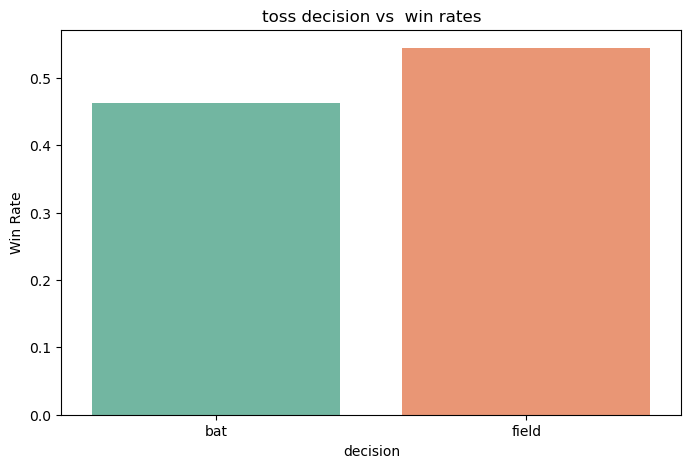

In [90]:
plt.figure(figsize=(8,5))
sns.barplot(x='decision', y='win_rate', data=toss_decision_win, palette='Set2')
plt.title('toss decision vs  win rates')
plt.ylabel('Win Rate')
plt.savefig('../player_stats/plot_toss.png', dpi=150)
plt.show()


**Visualizations of Top Venues**

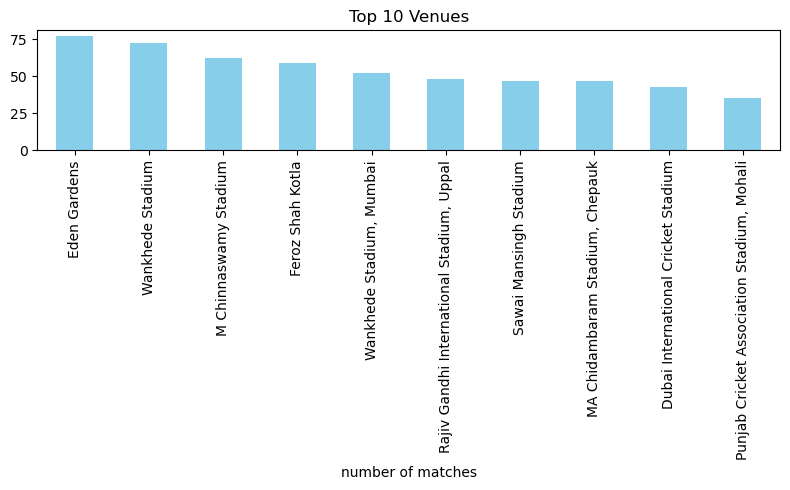

In [91]:
plt.figure(figsize=(8,5))
matches['venue'].value_counts().nlargest(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Venues')
plt.xlabel('number of matches')
plt.tight_layout()
plt.savefig('../player_stats/plot_venues.png', dpi=150)
plt.show()

**Visualizations of Batting First vs Chasing**

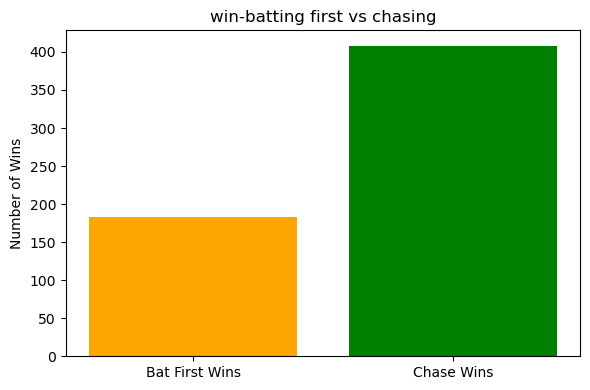

In [92]:
bat_win=len(matches[(matches['toss_decision'] == 'bat') & (matches['toss_winner'] == matches['winner'])])
chase_wins=len(matches[(matches['toss_decision'] == 'field') & (matches['toss_winner'] == matches['winner'])])
plt.figure(figsize=(6,4))
plt.bar(['Bat First Wins', 'Chase Wins'], [bat_win, chase_wins], color=['orange', 'green'])
plt.title('win-batting first vs chasing')
plt.ylabel('Number of Wins')
plt.tight_layout()
plt.savefig('../player_stats/plot_bat_chase.png', dpi=150)
plt.show()


**Visualizations of Top Batsmen**

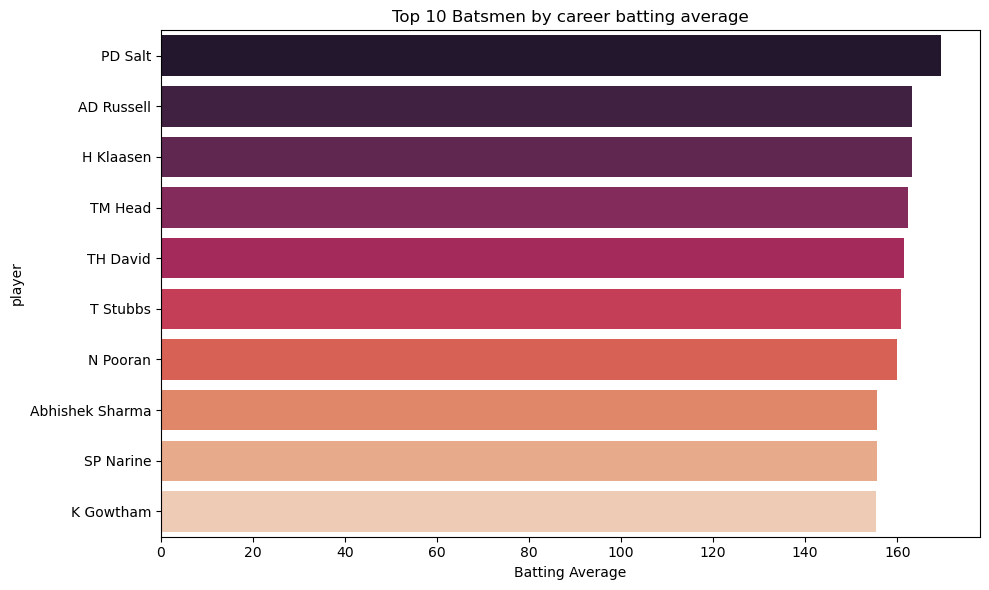

In [93]:
top_bat=player_lookup[player_lookup['innings'] >= 20].nlargest(10,'batting_avg')
plt.figure(figsize=(10,6))
sns.barplot(x='batting_avg', y='player', data=top_bat, palette='rocket')
plt.title('Top 10 Batsmen by career batting average')
plt.xlabel('Batting Average')
plt.tight_layout()
plt.savefig('../player_stats/plot_top_batsmen.png', dpi=150)
plt.show()

**Visualizations of Top Bowlers**

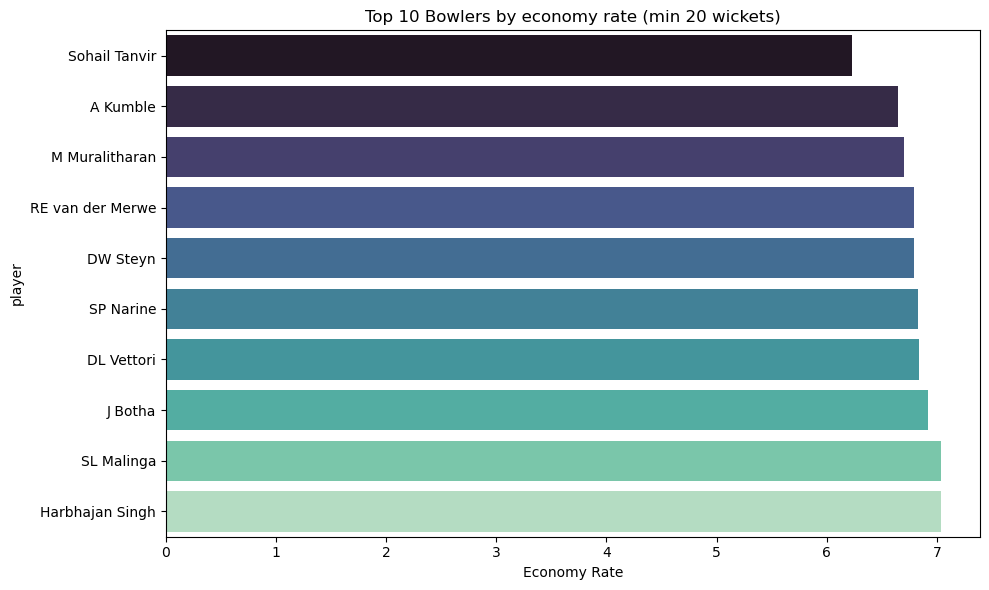

In [94]:
top_bowl=player_lookup[(player_lookup['wickets'] >=20)&(player_lookup['economy'] > 0)].nsmallest(10,'economy')
plt.figure(figsize=(10,6))
sns.barplot(x='economy', y='player', data=top_bowl, palette='mako')
plt.title('Top 10 Bowlers by economy rate (min 20 wickets)')
plt.xlabel('Economy Rate')
plt.tight_layout()
plt.savefig('../player_stats/plot_top_bowlers.png', dpi=150)
plt.show()


**Visualizations of Season Score Trend**

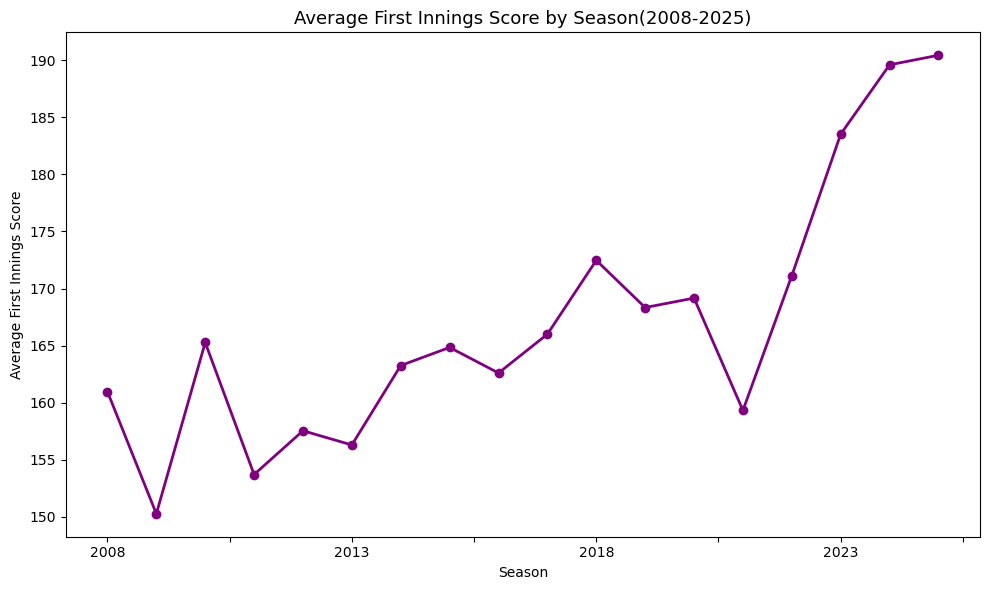

In [95]:
first_inn=deliveries[deliveries['inning'] == 1].groupby('match_id')['total_runs'].sum().reset_index()
first_inn.columns=['match_id','first_innings_score']
match_scores=matches.merge(first_inn, left_on='id', right_on='match_id', how='inner')
season_avg=match_scores.groupby('season')['first_innings_score'].mean()
plt.figure(figsize=(10,6))
season_avg.plot(marker='o', color='purple',linewidth=2)
plt.title('Average First Innings Score by Season(2008-2025)',fontsize=13)
plt.xlabel('Season')    
plt.ylabel('Average First Innings Score')
plt.tight_layout()
plt.savefig('../player_stats/plot_season_score.png', dpi=150)
plt.show()

**Model Training + Evaluation**

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, mean_absolute_error, confusion_matrix, classification_report,recall_score
from xgboost import XGBClassifier, XGBRegressor


In [97]:
df = pd.read_csv('../data/match_features.csv')
df['match_date'] = pd.to_datetime(df['match_date'])


In [98]:
df

,match_id,match_date,team1,team2,venue,venue_avg_first_innings,is_home_team1,toss_winner_is_team1,toss_decision_bat,h2h_team1_wins,...,t2_top3_batting_avg,t2_avg_economy,t2_avg_bowling_avg,t2_recent_strike_rate,t2_recent_economy,t1_opener_batting_avg,t1_opener_strike_rate,t2_opener_batting_avg,t2_opener_strike_rate,winner
0,335982,2008-04-18,5,12,23,167.000000,1,0,0,0,...,129.388273,8.604150,48.930365,93.413664,9.109307,134.036050,25.720853,134.633488,37.310472,1
1,335984,2008-04-19,1,10,16,167.000000,0,0,1,0,...,132.419143,7.972703,36.674811,90.250501,8.395833,142.493958,30.816949,138.337611,34.648193,1
2,335983,2008-04-19,9,0,41,167.000000,1,0,1,0,...,132.368097,8.413971,34.680409,85.656608,8.942857,134.277352,30.550007,128.437698,34.457316,0
3,335985,2008-04-20,7,12,56,167.000000,1,1,1,0,...,128.870665,8.674422,44.010244,102.465832,9.350000,124.557502,31.047720,134.633488,37.310472,0
4,335986,2008-04-20,13,5,14,167.000000,0,1,1,0,...,123.607760,8.245410,36.835246,73.958677,8.714286,138.165660,34.134123,134.036050,25.720853,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1141,1473507,2025-05-27,12,6,4,175.300000,1,1,0,3,...,149.754681,9.427553,35.998740,131.934950,9.866667,134.633488,37.310472,133.954818,34.966506,1
1142,1473508,2025-05-29,9,12,29,169.888889,0,0,0,18,...,148.419503,8.505120,46.734597,146.165657,9.108333,134.277352,30.550007,134.633488,37.310472,0
1143,1473509,2025-05-30,7,3,30,167.000000,0,1,1,2,...,144.312170,8.161088,35.464348,127.670754,9.267347,124.557502,31.047720,132.978153,38.810736,1
1144,1473510,2025-06-01,9,7,33,186.000000,1,1,0,15,...,153.596106,8.072908,31.245920,123.404870,8.530159,134.277352,30.550007,124.557502,31.047720,1


**Defineing Feature Columns**

In [99]:


feature_cols = [
    'team1', 'team2', 'venue',
    'venue_avg_first_innings',
    'is_home_team1',

    'toss_winner_is_team1',
    'toss_decision_bat',

    'h2h_team1_wins',
    'h2h_team2_wins',

    'chase_win_pct_team1',
    'chase_win_pct_team2',
    'high_score_chase_t1', 'high_score_chase_t2',

    'winrate_team1',
    'winrate_team2',

    'last5_win_team1',
    'last5_win_team2',
    't1_recent_avg_score', 't2_recent_avg_score',
    't1_pp_bowling_economy', 't2_pp_bowling_economy',

    't1_avg_batting_avg',
    't1_avg_strike_rate',
    't1_top3_batting_avg',
    't1_avg_economy',
    't1_avg_bowling_avg',
    't1_recent_strike_rate',
    't1_recent_economy',
    'season_avg_score',
    'season_year',

    't2_avg_batting_avg',
    't2_avg_strike_rate',
    't2_top3_batting_avg',
    't2_avg_economy',
    't2_avg_bowling_avg',
    't2_recent_strike_rate', 
    't2_recent_economy',
    't1_opener_batting_avg',
    't1_opener_strike_rate',
    't2_opener_batting_avg',
    't2_opener_strike_rate' 
]

train_df = df[df['match_date'] < '2024-01-01'].copy()
test_df = df[df['match_date'] >= '2024-01-01'].copy()

x_train = train_df[feature_cols].fillna(0)
y_train = train_df['winner']
x_test = test_df[feature_cols].fillna(0)
y_test = test_df['winner']


In [100]:

print(f"Test : {len(x_test)} matches (2024–2025)")
print(f"Features: {len(feature_cols)}")
print(f"\nTrain winner distribution:\n{y_train.value_counts()}")
print(f"\nTest winner distribution:\n{y_test.value_counts()}")


Test : 141 matches (2024–2025)
Features: 41

Train winner distribution:
winner
1    513
0    492
Name: count, dtype: int64

Test winner distribution:
winner
1    79
0    62
Name: count, dtype: int64


**Random Forest Classifier**

In [101]:
rf_clf = RandomForestClassifier(
    n_estimators=300,   
    max_depth=15,       
    min_samples_split=10,   
    min_samples_leaf=4,    
    max_features='sqrt',  
    bootstrap=True,         
    random_state=42,
    n_jobs=-1 ) 
rf_clf.fit(x_train, y_train)
rf_pred = rf_clf.predict(x_test)

In [102]:
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1  = f1_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)

In [103]:
print(f"Accuracy : {rf_acc:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"Recall   : {rf_rec:.4f}")


Accuracy : 0.7447
F1 Score : 0.7750
Recall   : 0.7848


**XGBoost Classifier**

In [104]:
xgb_clf = XGBClassifier(n_estimators=300, 
    max_depth=6, 
    learning_rate=0.05,
    subsample=0.8,   
    colsample_bytree=0.8,    
    reg_lambda=1.5,    
    reg_alpha=0.1,          
    random_state=42,
    eval_metric='logloss')
xgb_clf.fit(x_train, y_train)
xgb_pred = xgb_clf.predict(x_test)

In [105]:
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1  = f1_score(y_test, xgb_pred)
xgb_rec = recall_score(y_test, xgb_pred)

In [106]:
print(f"Accuracy : {xgb_acc:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"Recall   : {xgb_rec:.4f}")

Accuracy : 0.7518
F1 Score : 0.7742
Recall   : 0.7595


**Confusion Matrix**

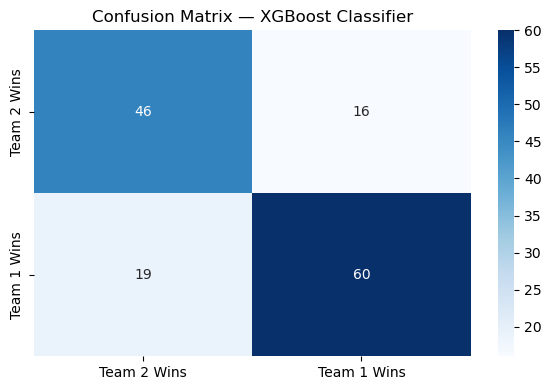

              precision    recall  f1-score   support

  Team2 Wins       0.71      0.74      0.72        62
  Team1 Wins       0.79      0.76      0.77        79

    accuracy                           0.75       141
   macro avg       0.75      0.75      0.75       141
weighted avg       0.75      0.75      0.75       141



In [107]:
cm = confusion_matrix(y_test, xgb_pred) # or rf_pred
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=['Team 2 Wins', 'Team 1 Wins'],
yticklabels=['Team 2 Wins', 'Team 1 Wins'])
plt.title('Confusion Matrix — XGBoost Classifier')
plt.tight_layout()
plt.savefig('../player_stats/plot_confusion_matrix.png', dpi=150)
plt.show()
print(classification_report(y_test, xgb_pred,
target_names=['Team2 Wins', 'Team1 Wins']))

**Feature Importance of my model**

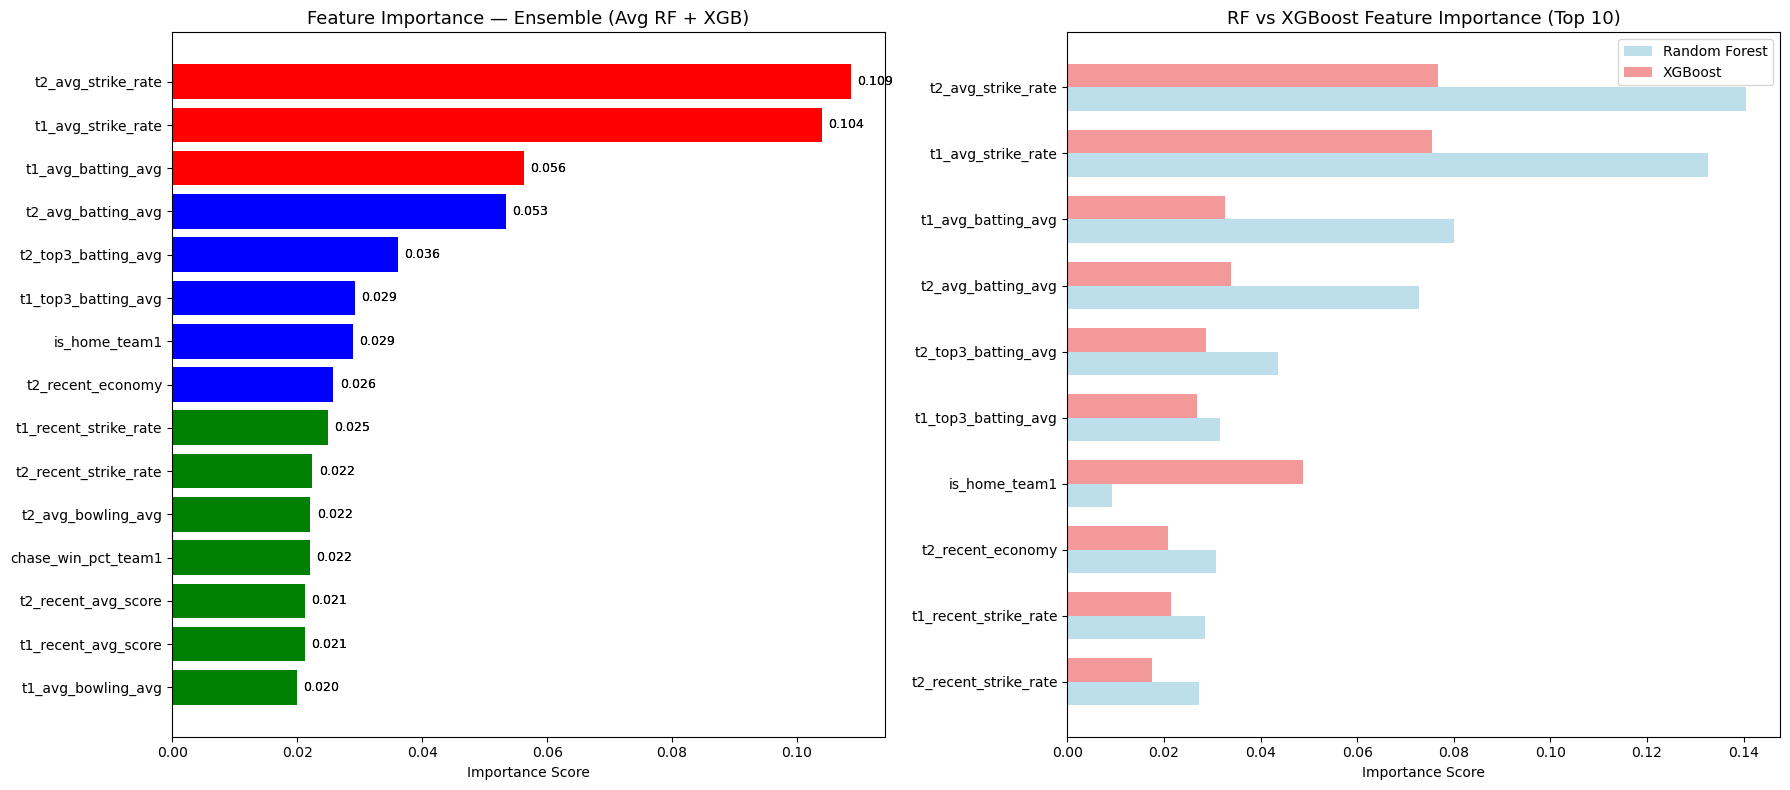

In [108]:
rf_importances = rf_clf.feature_importances_
xgb_importances = xgb_clf.feature_importances_
avg_importances = (rf_importances + xgb_importances) / 2
feat_df = pd.DataFrame({
    'feature'   : x_train.columns,
    'rf_imp'    : rf_importances,
    'xgb_imp'   : xgb_importances,
    'avg_imp'   : avg_importances
}).sort_values('avg_imp', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
top15 = feat_df.head(15)
colors = ['red' if i < 3 else 'blue' if i < 8 else 'green'
          for i in range(len(top15))]
axes[0].barh(top15['feature'], top15['avg_imp'], color=colors)
axes[0].set_title('Feature Importance — Ensemble (Avg RF + XGB)', fontsize=13)
axes[0].set_xlabel('Importance Score')
axes[0].invert_yaxis()
for i, (val, feat) in enumerate(zip(top15['avg_imp'], top15['feature'])):
    axes[0].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)
for i, (val, feat) in enumerate(zip(top15['avg_imp'], top15['feature'])):
    axes[0].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)
    top10 = feat_df.head(10)
x_pos = np.arange(len(top10))
width = 0.35
axes[1].barh(x_pos + width/2, top10['rf_imp'],  width, label='Random Forest', color='lightblue', alpha=0.8)
axes[1].barh(x_pos - width/2, top10['xgb_imp'], width, label='XGBoost',       color='lightcoral', alpha=0.8)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(top10['feature'])
axes[1].invert_yaxis()
axes[1].set_title('RF vs XGBoost Feature Importance (Top 10)', fontsize=13)
axes[1].set_xlabel('Importance Score')
axes[1].legend()
plt.tight_layout()
plt.savefig('../player_stats/plot_feature_importance.png', dpi=150)
plt.show()


**Saveing Best Winner Model**

In [109]:
best_clf = xgb_clf if xgb_acc >= rf_acc else rf_clf
best_clf_name = 'XGBoost' if xgb_acc >= rf_acc else 'RandomForest'
joblib.dump(best_clf, '../models/winner_model.pkl')
print(f'{best_clf_name} winner model saved (accuracy: {max(xgb_acc, rf_acc):.4f})')

XGBoost winner model saved (accuracy: 0.7518)


**Score Predictor: Prepareing Data**

In [110]:
first_innings=deliveries[deliveries['inning'] == 1].groupby('match_id')['total_runs'].sum().reset_index()
first_innings.columns=['match_id','first_innings_score']
print(first_innings.head())
print(first_innings['first_innings_score'].describe())

   match_id  first_innings_score
0    335982                  222
1    335983                  240
2    335984                  129
3    335985                  165
4    335986                  110
count    1169.000000
mean      167.021386
std        32.948414
min        56.000000
25%       147.000000
50%       167.000000
75%       188.000000
max       287.000000
Name: first_innings_score, dtype: float64


**Merge and Split for Regressio**n

In [111]:
df_score=df.merge(first_innings, left_on='match_id', right_on='match_id', how='inner')
df_score['match_date'] = pd.to_datetime(df_score['match_date'])
score_train = df_score[df_score['match_date'] < '2024-01-01']
score_test = df_score[df_score['match_date'] >= '2024-01-01']
xs_train = score_train[feature_cols].fillna(0)
ys_train = score_train['first_innings_score']
xs_test = score_test[feature_cols].fillna(0)
ys_test = score_test['first_innings_score']


In [112]:
print(f"Score train: {len(xs_train)} | Score test: {len(xs_test)}")
print(f"Score range: {ys_train.min():.0f} – {ys_train.max():.0f} runs")


Score train: 1005 | Score test: 141
Score range: 67 – 263 runs


**Training Score Models**

**random Forest Regressor**

In [113]:
rf_reg=RandomForestRegressor(n_estimators=300,       
    max_depth=8,        
    min_samples_split=10,   
    min_samples_leaf=4,     
    max_features='sqrt', 
    bootstrap=True, random_state=42)
rf_reg.fit(xs_train, ys_train) 
rf_reg_pred = rf_reg.predict(xs_test)
rf_rmse = np.sqrt(mean_squared_error(ys_test, rf_reg_pred))
rf_mae = mean_absolute_error(ys_test, rf_reg_pred)
print(rf_rmse)
print(rf_mae)

38.20999884346388
29.73960276518382


In [114]:
from sklearn.linear_model import LinearRegression   
lin_reg = LinearRegression()
lin_reg.fit(xs_train, ys_train)
lin_reg_pred = lin_reg.predict(xs_test)
lin_rmse = np.sqrt(mean_squared_error(ys_test, lin_reg_pred))
lin_mae = mean_absolute_error(ys_test, lin_reg_pred)
print(lin_rmse)
print(lin_mae)


36.4101233504295
28.24833535510645


**XGBoost Regressor**

In [115]:
xgb_reg = XGBRegressor(
    n_estimators=200,
    max_depth=5,         
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.8,
    reg_lambda=2.0,
    random_state=42,
    eval_metric='rmse'
)
xgb_reg.fit(xs_train, ys_train)
xgb_reg_pred = xgb_reg.predict(xs_test)
xgb_rmse= np.sqrt(mean_squared_error(ys_test, xgb_reg_pred))
xgb_mae= mean_absolute_error(ys_test, xgb_reg_pred)


In [116]:
print(f"RF  : {rf_rmse:.2f}")
print(f"XGB : {xgb_rmse:.2f}")
print(f"Best: {'XGBoost' if xgb_rmse <= rf_rmse else 'Random Forest'}")

RF  : 38.21
XGB : 38.76
Best: Random Forest


In [117]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
level0 = [
    ('xgb', XGBRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0,
        random_state=42, eval_metric='rmse'
    )),
    ('rf', RandomForestRegressor(
        n_estimators=200, max_depth=8, min_samples_leaf=4,
        random_state=42
    )),
]

level1 = Ridge(alpha=1.0)

stacking_reg = StackingRegressor(
    estimators=level0,
    final_estimator=level1,
    cv=5,
    n_jobs=-1
)
stacking_reg.fit(xs_train, ys_train)
stack_pred = stacking_reg.predict(xs_test)
stack_rmse = np.sqrt(mean_squared_error(ys_test, stack_pred))
stack_mae  = mean_absolute_error(ys_test, stack_pred)

print(f"Stacking RMSE : {stack_rmse:.2f} runs")
print(f"Stacking MAE  : {stack_mae:.2f} runs")

rf_reg_pred  = rf_reg.predict(xs_test)
rf_rmse      = np.sqrt(mean_squared_error(ys_test, rf_reg_pred))
rf_mae       = mean_absolute_error(ys_test, rf_reg_pred)
print(f"\nRF    RMSE: {rf_rmse:.2f}")
print(f"Stack RMSE: {stack_rmse:.2f}")

Stacking RMSE : 39.13 runs
Stacking MAE  : 30.43 runs

RF    RMSE: 38.21
Stack RMSE: 39.13


In [118]:
powerplay_eco = (
    deliveries[(deliveries['inning'] == 1) & (deliveries['over_number'] <= 6)]
    .groupby(['match_id', 'bowling_team'])
    .agg(pp_runs=('total_runs', 'sum'), pp_balls=('ball_number', 'count'))
    .reset_index()
)
powerplay_eco['pp_economy'] = (powerplay_eco['pp_runs'] / powerplay_eco['pp_balls']) * 6

team_pp_eco = (
    powerplay_eco.groupby('bowling_team')['pp_economy']
    .mean().reset_index()
    .rename(columns={'bowling_team': 'team', 'pp_economy': 'avg_pp_economy'})
)

In [119]:
powerplay_eco.head()

,match_id,bowling_team,pp_runs,pp_balls,pp_economy
0,335982,Royal Challengers Bangalore,68,44,9.272727
1,335983,Punjab Kings,62,44,8.454545
2,335984,Delhi Capitals,44,43,6.139535
3,335985,Royal Challengers Bangalore,54,44,7.363636
4,335986,Kolkata Knight Riders,45,45,6.000000


**opner runs model**

In [120]:
first_inn_del = deliveries[deliveries['inning'] == 1].copy()

def get_opener_pair_runs(group):

    group = group.sort_values('ball_number')

    openers = []
    for batsman in group['batsman']:
        if batsman not in openers:
            openers.append(batsman)
        if len(openers) == 2:
            break

    if not openers:
        return 0

    opener_runs = group[group['batsman'].isin(openers)]['batsman_runs'].sum()
    return int(opener_runs)


In [121]:
opener_runs_per_match = (
    first_inn_del
    .groupby(['match_id', 'batting_team'])
    .apply(get_opener_pair_runs)
    .reset_index()
    .rename(columns={0: 'opener_runs'})
)

In [122]:
joblib.dump(team_encoder, '../models/team_encoder.pkl')
opener_runs_encoded = opener_runs_per_match.copy()


In [123]:
known_teams = set(team_encoder.classes_)
opener_runs_encoded = opener_runs_encoded[
    opener_runs_encoded['batting_team'].isin(known_teams)
]
opener_runs_encoded['batting_team'] = team_encoder.transform(
    opener_runs_encoded['batting_team']
)

In [124]:
joblib.dump(team_encoder, '../models/team_encoder.pkl')
team_pp_eco_clean = team_pp_eco.copy()
team_pp_eco_clean = team_pp_eco_clean[
    team_pp_eco_clean['team'].isin(set(team_encoder.classes_))
]
team_pp_eco_clean['team'] = team_encoder.transform(team_pp_eco_clean['team'])

print("PP eco cleaned shape:", team_pp_eco_clean.shape)

PP eco cleaned shape: (14, 2)


In [125]:
df_opener = df.merge(
    opener_runs_encoded,
    left_on=['match_id', 'team1'],
    right_on=['match_id', 'batting_team'],
    how='inner'
)

df_opener = df_opener.merge(
    team_pp_eco_clean.rename(columns={'team': 'team2_enc', 'avg_pp_economy': 'opp_pp_economy'}),
    left_on='team2',
    right_on='team2_enc',
    how='left'
)
df_opener['opp_pp_economy'] = df_opener['opp_pp_economy'].fillna(8.5)


opener_feature_cols = [
    't1_opener_batting_avg',  
    't1_opener_strike_rate',  
    't1_recent_strike_rate', 
    't1_recent_avg_score',
    'opp_pp_economy', 
    'venue_avg_first_innings',   
    'toss_decision_bat',
    'is_home_team1',
    't1_top3_batting_avg',   
    'season_year', 
    'season_avg_score', 
]



df_opener['match_date'] = pd.to_datetime(df_opener['match_date'])
opener_train = df_opener[df_opener['match_date'] < '2024-01-01']
opener_test  = df_opener[df_opener['match_date'] >= '2024-01-01']
xo_train = opener_train[opener_feature_cols].fillna(0)
yo_train = opener_train['opener_runs']
xo_test  = opener_test[opener_feature_cols].fillna(0)
yo_test  = opener_test['opener_runs']





In [126]:
xgb_opener = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2.0, 
    random_state=42,
    eval_metric='rmse')
xgb_opener.fit(xo_train, yo_train)
opener_pred = xgb_opener.predict(xo_test)  
opener_rmse = np.sqrt(mean_squared_error(yo_test, opener_pred))
opener_mae = mean_absolute_error(yo_test, opener_pred)
print(f"Opener Runs Prediction RMSE: {opener_rmse:.2f}")
print(f"Opener Runs Prediction MAE : {opener_mae:.2f}")

Opener Runs Prediction RMSE: 36.96
Opener Runs Prediction MAE : 31.18


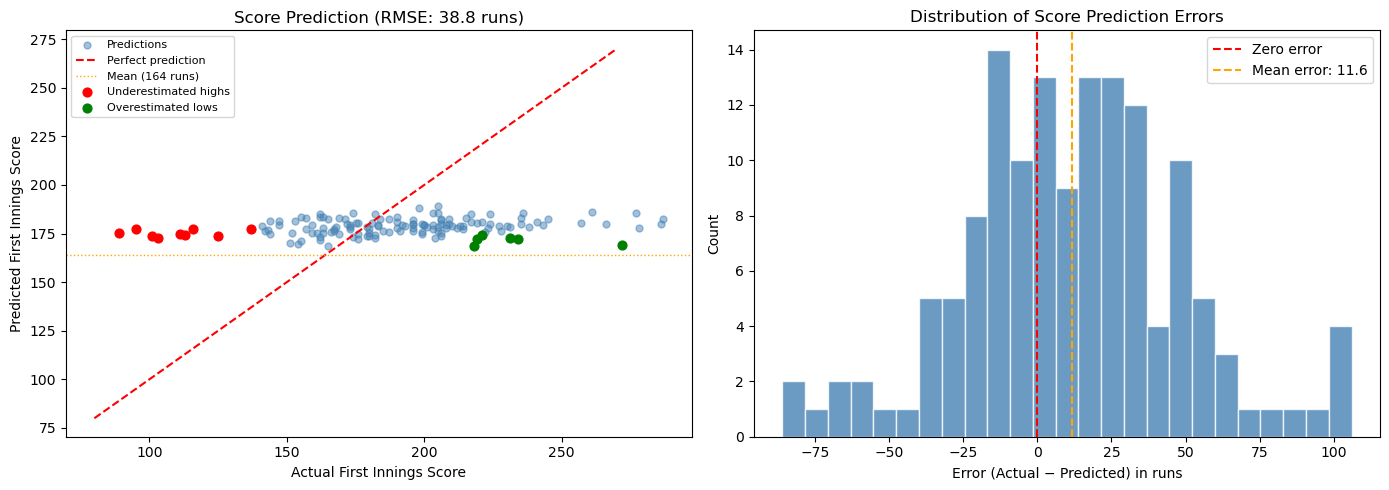


Score model summary:
  RMSE = 38.8 runs (avg error)
  MAE  = 30.2 runs


In [127]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

best_reg_pred = stack_pred if stack_rmse <= xgb_rmse else xgb_reg_pred
best_rmse     = min(stack_rmse, xgb_rmse)
axes[0].scatter(ys_test, best_reg_pred, alpha=0.5, color='steelblue', s=25, label='Predictions')
axes[0].plot([80, 270], [80, 270], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].axhline(y=ys_train.mean(), color='orange', linestyle=':', linewidth=1, label=f'Mean ({ys_train.mean():.0f} runs)')
under = (ys_test < 140) & (best_reg_pred > 155)
over  = (ys_test > 210) & (best_reg_pred < 175)
axes[0].scatter(ys_test[under], best_reg_pred[under], color='red',  s=40, zorder=5, label='Underestimated highs')
axes[0].scatter(ys_test[over],  best_reg_pred[over],  color='green',s=40, zorder=5, label='Overestimated lows')
axes[0].set_xlabel('Actual First Innings Score')
axes[0].set_ylabel('Predicted First Innings Score')
axes[0].set_title(f'Score Prediction (RMSE: {best_rmse:.1f} runs)', fontsize=12)
axes[0].legend(fontsize=8)

residuals = ys_test.values - best_reg_pred
axes[1].hist(residuals, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[1].axvline(residuals.mean(), color='orange', linestyle='--', linewidth=1.5, 
                label=f'Mean error: {residuals.mean():.1f}')
axes[1].set_xlabel('Error (Actual − Predicted) in runs')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Score Prediction Errors')
axes[1].legend()

plt.tight_layout()
plt.savefig('../player_stats/plot_score_prediction.png', dpi=150)
plt.show()

print(f"\nScore model summary:")
print(f"  RMSE = {best_rmse:.1f} runs (avg error)")
print(f"  MAE  = {mean_absolute_error(ys_test, best_reg_pred):.1f} runs")

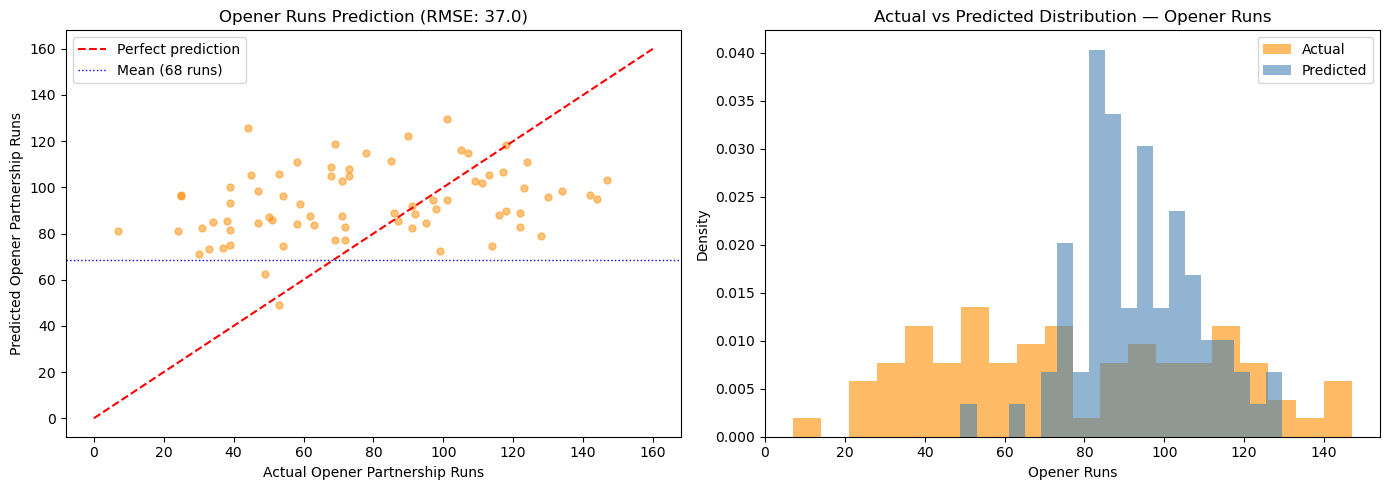


Opener model summary:
  RMSE = 37.0 runs
  MAE  = 31.2 runs
  Avg actual opener runs: 77.4
  Avg predicted          : 93.3


In [128]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(yo_test, opener_pred, alpha=0.5, color='darkorange', s=25)
axes[0].plot([0, 160], [0, 160], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].axhline(y=yo_train.mean(), color='blue', linestyle=':', linewidth=1, 
                label=f'Mean ({yo_train.mean():.0f} runs)')
axes[0].set_xlabel('Actual Opener Partnership Runs')
axes[0].set_ylabel('Predicted Opener Partnership Runs')
axes[0].set_title(f'Opener Runs Prediction (RMSE: {opener_rmse:.1f})', fontsize=12)
axes[0].legend()
axes[1].hist(yo_test, bins=20, alpha=0.6, color='darkorange', label='Actual', density=True)
axes[1].hist(opener_pred, bins=20, alpha=0.6, color='steelblue', label='Predicted', density=True)
axes[1].set_xlabel('Opener Runs')
axes[1].set_ylabel('Density')
axes[1].set_title('Actual vs Predicted Distribution — Opener Runs')
axes[1].legend()

plt.tight_layout()
plt.savefig('../player_stats/plot_opener_prediction.png', dpi=150)
plt.show()

print(f"\nOpener model summary:")
print(f"  RMSE = {opener_rmse:.1f} runs")
print(f"  MAE  = {opener_mae:.1f} runs")
print(f"  Avg actual opener runs: {yo_test.mean():.1f}")
print(f"  Avg predicted          : {opener_pred.mean():.1f}")

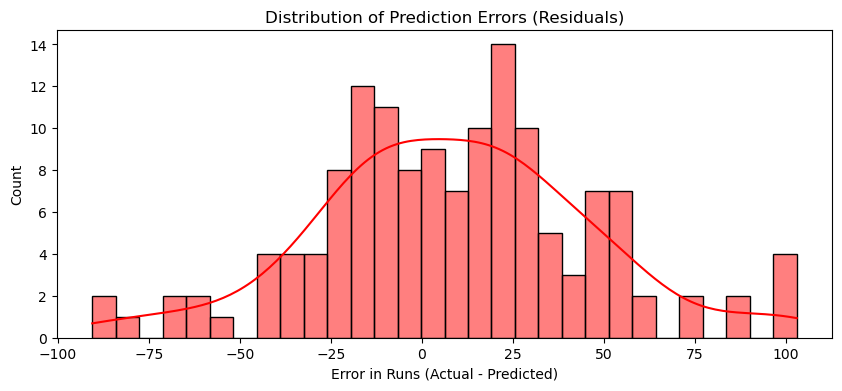

In [129]:
residuals = ys_test - (xgb_reg_pred if xgb_rmse <= rf_rmse else rf_reg_pred)
plt.figure(figsize=(10, 4))
sns.histplot(residuals, bins=30, kde=True, color='red')
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Error in Runs (Actual - Predicted)')
plt.savefig('../player_stats/plot_baised_toward_score.png', dpi=150)
plt.show()

In [130]:

from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)
rf_cv  = cross_val_score(rf_clf,  x_train, y_train, cv=tscv, scoring='accuracy')
xgb_cv = cross_val_score(xgb_clf, x_train, y_train, cv=tscv, scoring='accuracy')

print("RF  CV accuracy:", rf_cv.round(3), f"→ mean {rf_cv.mean():.3f} ± {rf_cv.std():.3f}")
print("XGB CV accuracy:", xgb_cv.round(3), f"→ mean {xgb_cv.mean():.3f} ± {xgb_cv.std():.3f}")

RF  CV accuracy: [0.79  0.725 0.731 0.784 0.737] → mean 0.753 ± 0.028
XGB CV accuracy: [0.79  0.707 0.725 0.76  0.76 ] → mean 0.749 ± 0.030


**Save Best Score Model**

In [131]:


if stack_rmse <= xgb_rmse:
    best_reg  = stacking_reg
    best_name = 'Stacking (XGB+RF+Ridge)'
    best_rmse_final = stack_rmse
else:
    best_reg  = xgb_reg
    best_name = 'XGBoost'
    best_rmse_final = xgb_rmse

joblib.dump(best_reg, '../models/score_model.pkl')
print(f"{best_name} saved as score model")
print(f"   RMSE: {best_rmse_final:.2f} runs")

XGBoost saved as score model
   RMSE: 38.76 runs
